# Báo cáo Metric — Hệ thống phát hiện SQL Injection

**Ngày:** 21/07/2026  |  **Kiến trúc:** 2 nhánh (Nhánh 1 Supervised + Nhánh 2 Anomaly)

File này tổng hợp toàn bộ metric thực nghiệm cho báo cáo Ban 1 (nộp 25/07).

In [1]:
import json, csv
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, HTML, Image

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORTS = PROJECT / 'reports'
FIGURES = REPORTS / 'figures'

with open(REPORTS / 'nhanh1_eval.json') as f:
    r1 = json.load(f)
with open(REPORTS / 'nhanh2_eval.json') as f:
    r2 = json.load(f)

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 10)

---
## 1. Nhánh 1 — Supervised Multi-class (TF-IDF + Logistic Regression)

In [2]:
print(f"Kiến trúc: {r1['chosen_architecture']}")
print(f"F1-macro: {r1['f1_macro']:.4f}")
print(f"Train: {r1['train_rows']}  |  Test: {r1['test_rows']}")
print(f"\nCaveats:")
for c in r1['caveats']:
    print(f"  • {c}")

Kiến trúc: tfidf_logreg
F1-macro: 0.9822
Train: 54236  |  Test: 13560

Caveats:
  • boolean_blind class has ~13% measured label noise (see data_contract.md Muc 3.1).
  • True robustness must be measured on the Day-7 adversarial test set, not this clean test split.
  • stacked class excluded from training (16/7) - see data_contract.md Muc 3.3.


In [3]:
df1 = pd.DataFrame(r1['per_class']).T
df1.index.name = 'Class'
display(df1.style.format({
    'precision': '{:.4f}', 'recall': '{:.4f}',
    'f1-score': '{:.4f}', 'support': '{:.0f}'
}).background_gradient(cmap='RdYlGn', subset=['precision', 'recall', 'f1-score']))

,precision,recall,f1-score,support
Class,,,,
normal,0.9657,0.9470,0.9562,3000
union_based,0.9993,0.9903,0.9948,3000
error_based,0.9981,1.0000,0.9990,1560
boolean_blind,0.9484,0.9740,0.9610,3000
time_blind,0.9997,1.0000,0.9998,3000


In [4]:
labels = r1['confusion_matrix_labels']
cm = np.array(r1['confusion_matrix'])
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = 'Actual\\Predicted'
display(cm_df)

,normal,union_based,error_based,boolean_blind,time_blind
Actual\Predicted,,,,,
normal,2841,2,0,157,0
union_based,27,2971,0,2,0
error_based,0,0,1560,0,0
boolean_blind,74,0,3,2922,1
time_blind,0,0,0,0,3000


AUC per class (One-vs-Rest):
  normal              : AUC = 0.9982
  union_based         : AUC = 1.0000
  error_based         : AUC = 1.0000
  boolean_blind       : AUC = 0.9983
  time_blind          : AUC = 1.0000


,class,auc
0,normal,0.9982
1,union_based,1.0000
2,error_based,1.0000
3,boolean_blind,0.9983
4,time_blind,1.0000


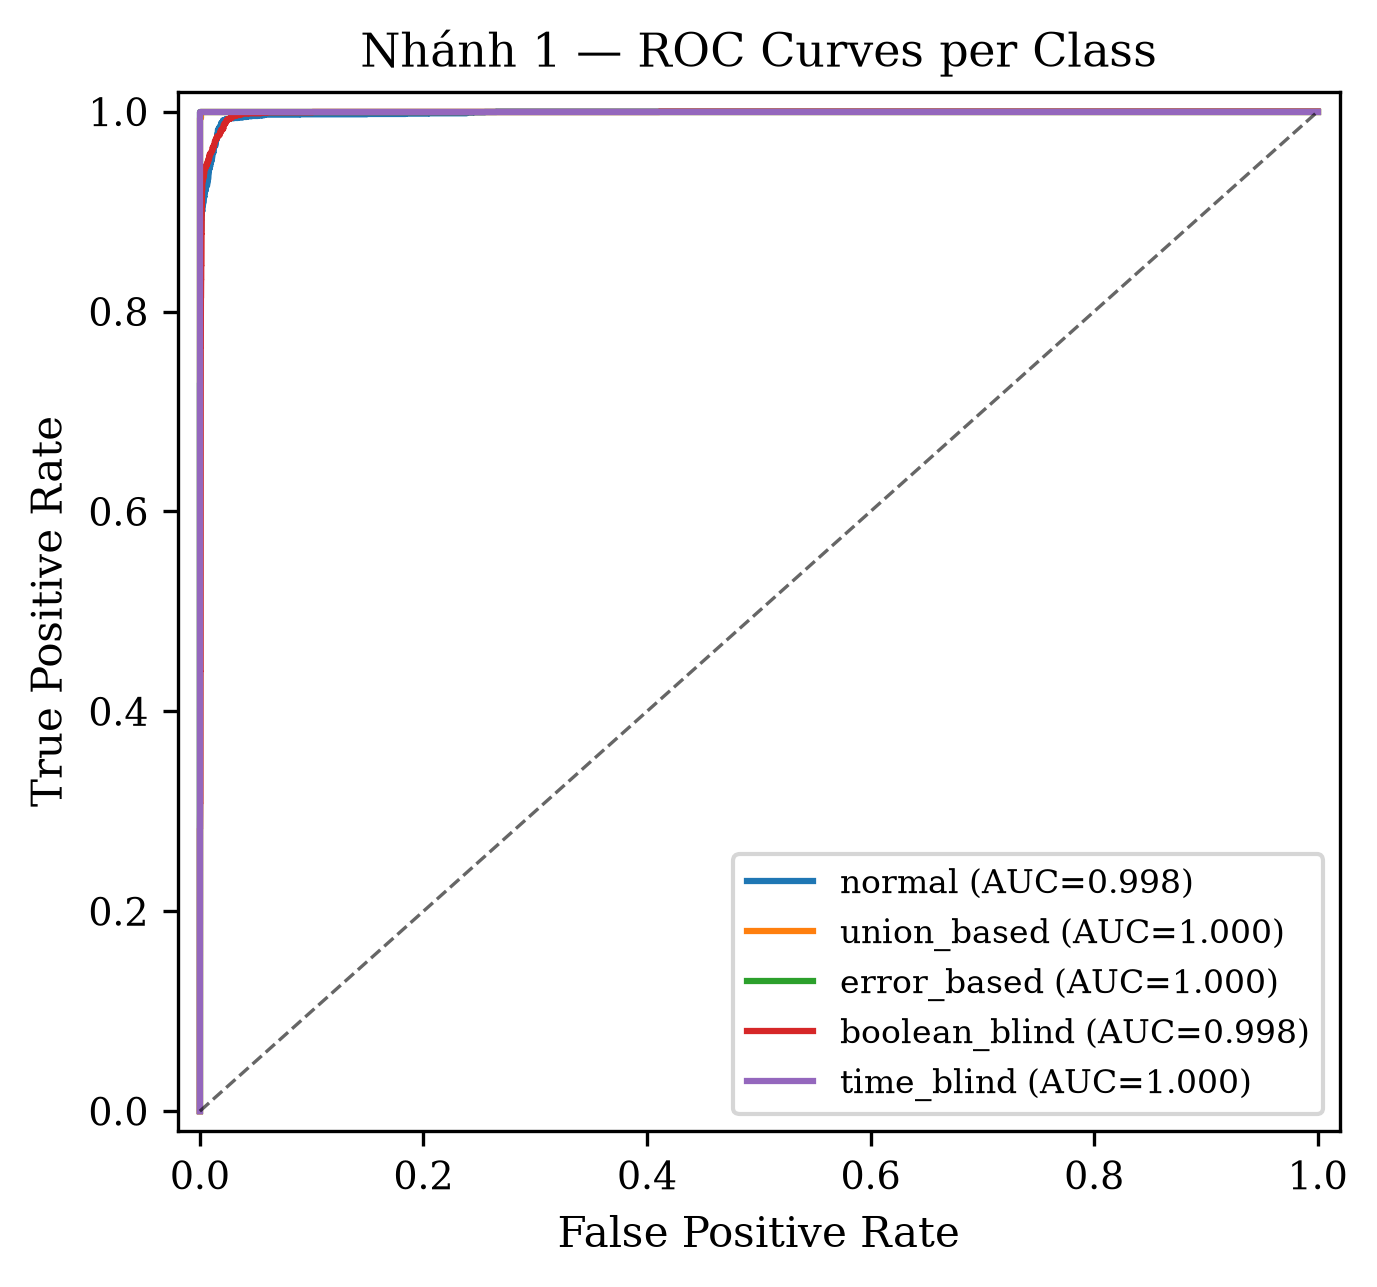

In [5]:
print("AUC per class (One-vs-Rest):")
roc_data = []
for k, v in r1.get('roc_curves_per_class', {}).items():
    roc_data.append({'class': v['label'], 'auc': v['auc']})
    print(f"  {v['label']:20s}: AUC = {v['auc']:.4f}")

roc_df = pd.DataFrame(roc_data)
display(roc_df)

fig_path = FIGURES / 'nhanh1_roc_per_class.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))

---
## 2. Nhánh 2 — Anomaly Detection (One-Class SVM)

In [6]:
chosen = r2['chosen']
print(f"Thuật toán: {chosen['algorithm']}")
print(f"Train: {r2['train_rows']} benign")
print(f"Test benign: {chosen['n_benign']}  |  Anomalous: {chosen['n_anomalous']}")
print(f"\nAUC: {chosen['auc']:.4f}")
print(f"AP (Average Precision): {r2.get('average_precision', 'N/A')}")
print(f"FPR: {chosen['fpr']*100:.2f}% ({chosen['n_false_positives']}/{chosen['n_benign']})")
print(f"DR: {chosen['detection_rate']*100:.2f}% ({chosen['n_true_positives']}/{chosen['n_anomalous']})")

Thuật toán: one_class_svm
Train: 12000 benign
Test benign: 3000  |  Anomalous: 25065

AUC: 0.9016
AP (Average Precision): 0.9819
FPR: 0.30% (9/3000)
DR: 20.73% (5196/25065)


In [7]:
cm2 = r2.get('confusion_matrix', {})
cm2_df = pd.DataFrame([
    [cm2.get('tn',0), cm2.get('fp',0)],
    [cm2.get('fn',0), cm2.get('tp',0)]
], index=['Actual Normal', 'Actual Anomaly'],
   columns=['Pred Normal', 'Pred Anomaly'])
display(cm2_df)

,Pred Normal,Pred Anomaly
Actual Normal,2991,9
Actual Anomaly,19869,5196


In [8]:
print("Detection Rate per source:")
pcd_data = []
for k, v in r2.get('per_class_detection_rate', {}).items():
    pcd_data.append({'source': k, 'total': v['total'],
                     'detected': v['detected'], 'dr': v['dr']})
    print(f"  {k:20s}: DR={v['dr']*100:.2f}% ({v['detected']}/{v['total']})")
if pcd_data:
    display(pd.DataFrame(pcd_data))

Detection Rate per source:
  d3_csic2010         : DR=20.73% (5196/25065)


,source,total,detected,dr
0,d3_csic2010,25065,5196,0.2073



nhanh2_pr_curve.png:


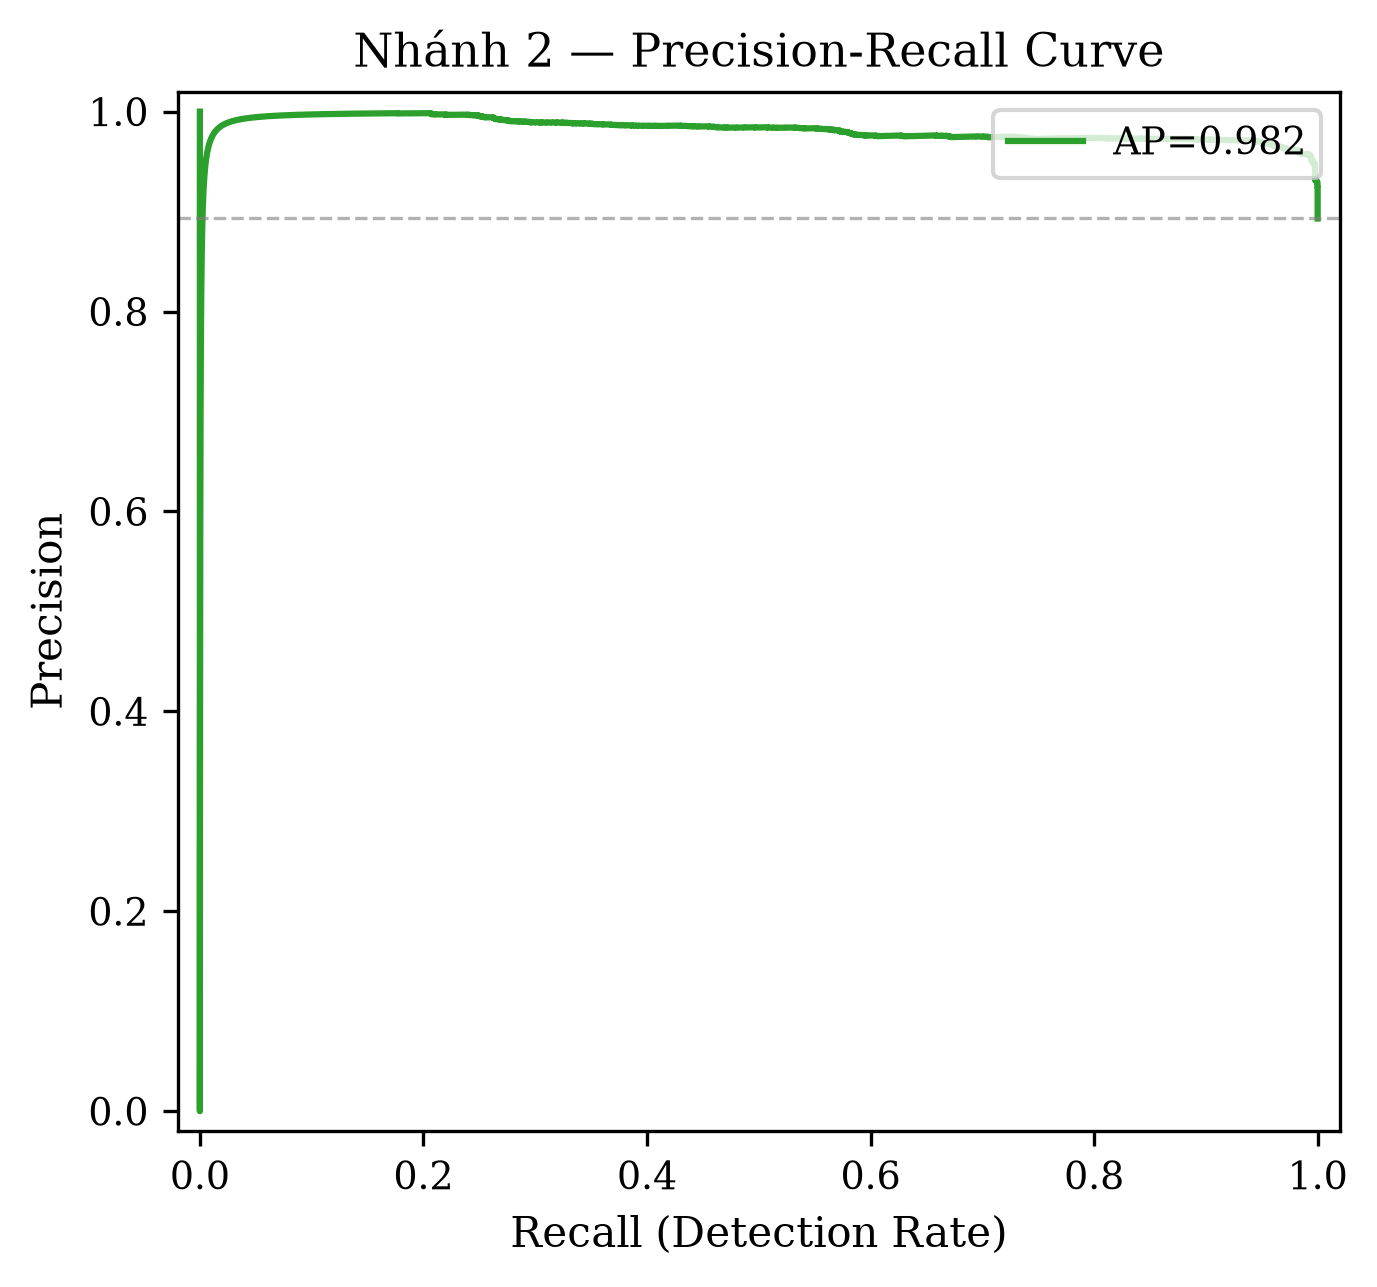


nhanh2_score_dist.png:


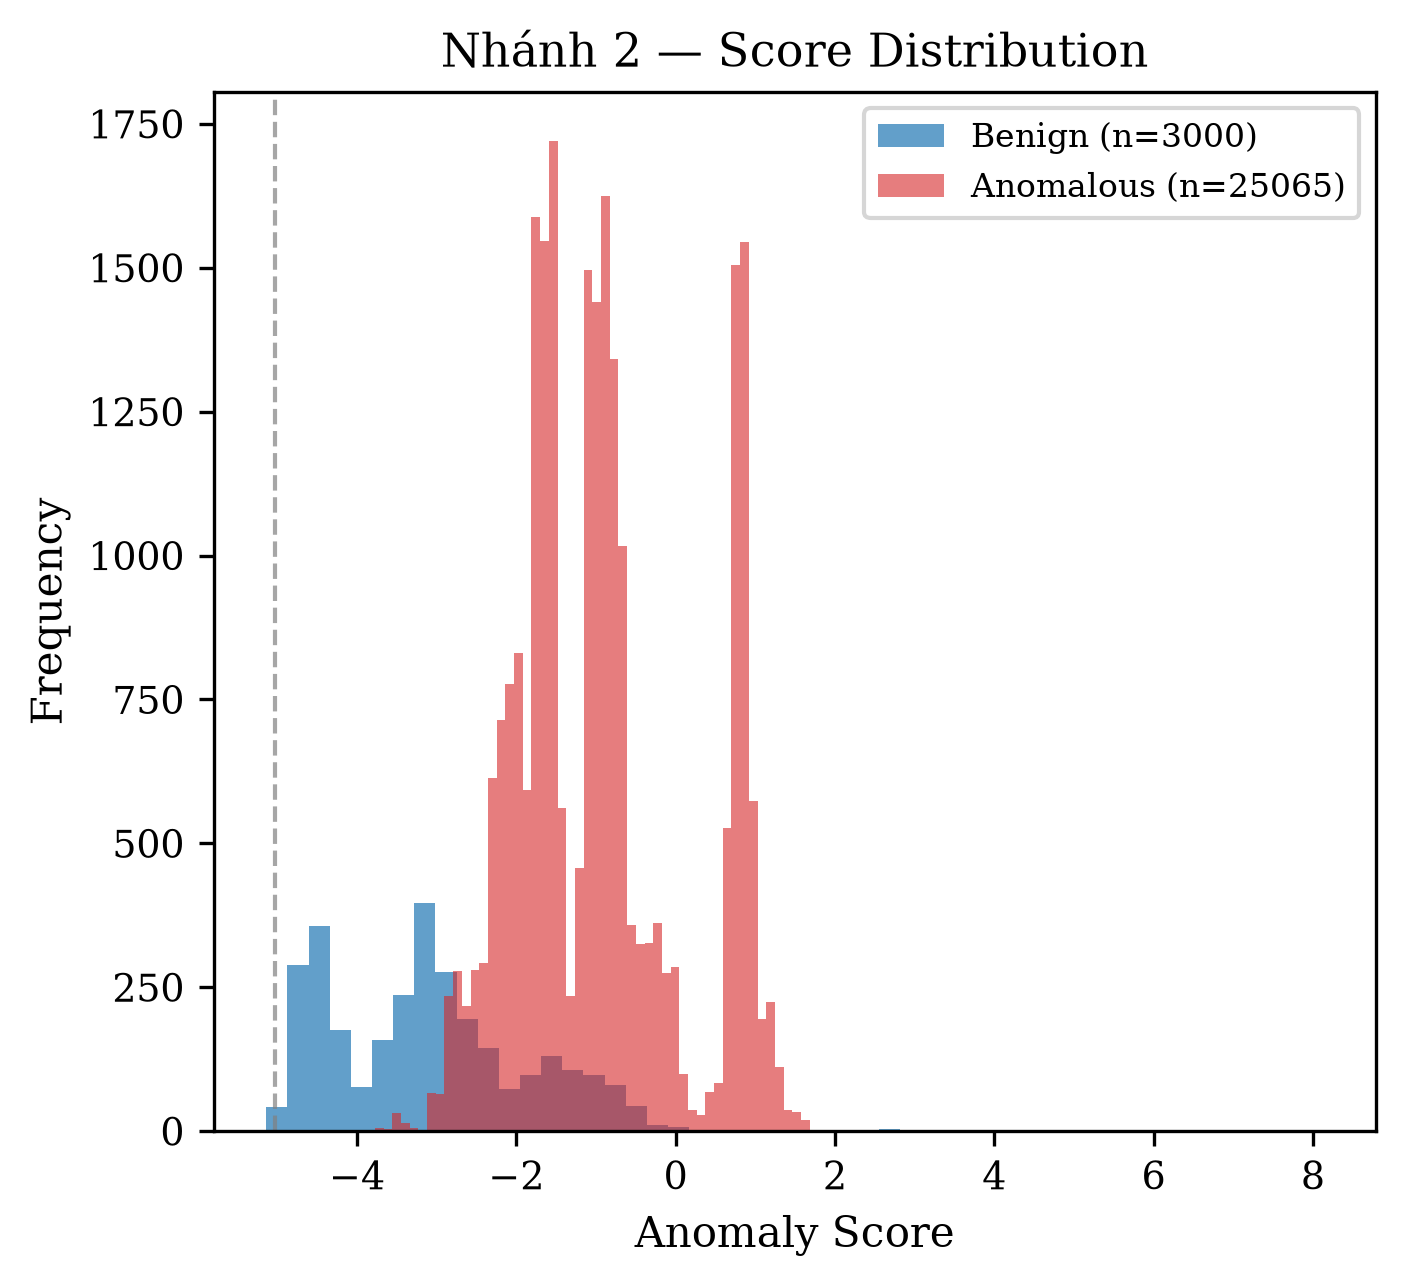


nhanh2_threshold_tradeoff.png:


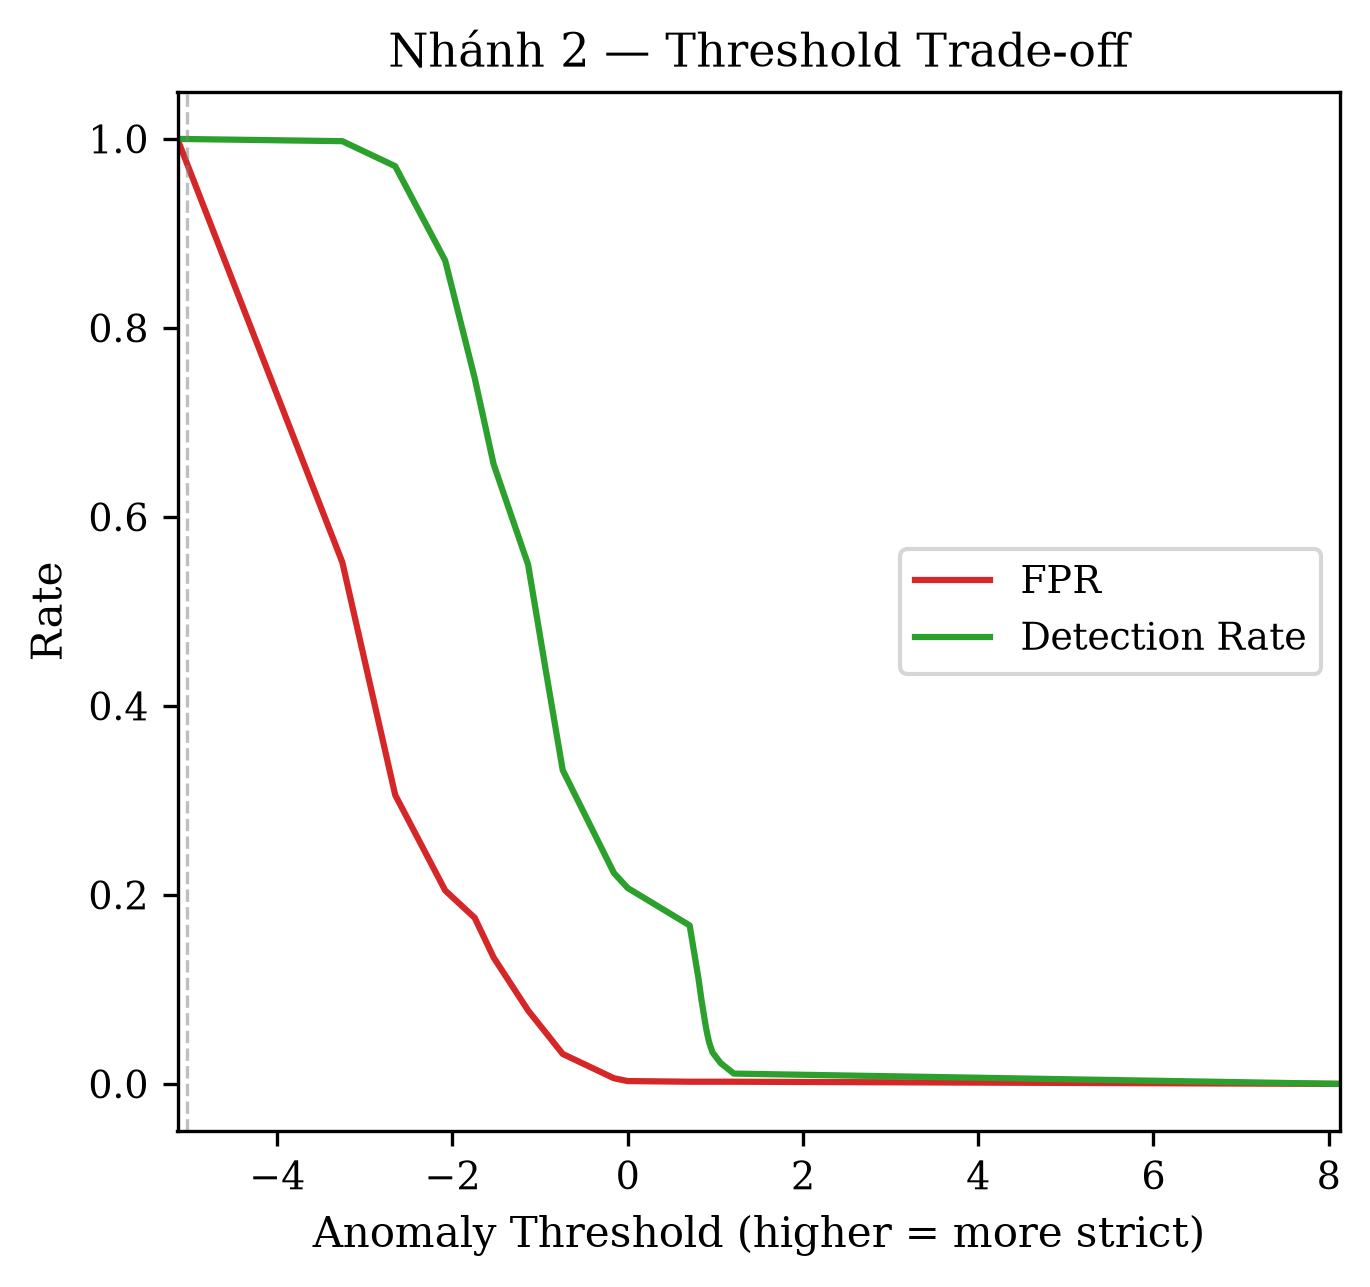

In [9]:
for fname in ['nhanh2_pr_curve.png', 'nhanh2_score_dist.png', 'nhanh2_threshold_tradeoff.png']:
    fp = FIGURES / fname
    if fp.exists():
        print(f"\n{fname}:")
        display(Image(filename=str(fp)))

In [10]:
sweep = pd.read_csv(REPORTS / 'nhanh2_threshold_sweep.csv')
display(sweep.style.format({
    'threshold': '{:.4f}', 'fpr': '{:.4f}', 'dr': '{:.4f}',
    'precision': '{:.4f}'
}).background_gradient(cmap='RdYlGn_r', subset=['fpr']))

,threshold,fpr,dr,precision,fp_count,tp_count,tn_count,fn_count
0,8.1294,0.0000,0.0000,0.0000,0,0,3000,25065
1,1.2114,0.0023,0.0109,0.9751,7,274,2993,24791
2,1.0606,0.0023,0.0221,0.9875,7,555,2993,24510
3,0.9681,0.0023,0.0333,0.9917,7,835,2993,24230
4,0.9280,0.0023,0.0445,0.9938,7,1116,2993,23949
5,0.9015,0.0023,0.0557,0.9950,7,1397,2993,23668
6,0.8805,0.0023,0.0669,0.9958,7,1677,2993,23388
7,0.8415,0.0023,0.0893,0.9969,7,2239,2993,22826
8,0.8079,0.0023,0.1117,0.9975,7,2800,2993,22265
9,0.7073,0.0023,0.1677,0.9983,7,4203,2993,20862


---
## 3. So sánh kiến trúc Nhánh 1

In [11]:
try:
    with open(REPORTS / 'nhanh1_architecture_comparison.json') as f:
        arch = json.load(f)
    arch_rows = []
    for k, v in arch.get('candidates', {}).items():
        arch_rows.append({
            'Architecture': k,
            'F1-macro': v.get('f1_macro', 'N/A'),
            'Latency (ms)': v.get('latency_ms', {}).get('p50', 'N/A'),
            'Size (MB)': v.get('model_size_mb', 'N/A'),
            'Train time (s)': v.get('train_time_s', 'N/A'),
        })
    arch_df = pd.DataFrame(arch_rows)
    display(arch_df)
except FileNotFoundError:
    print("Không tìm thấy nhanh1_architecture_comparison.json")

""


---
## 4. Tổng kết

| Metric | Nhánh 1 | Nhánh 2 |
|--------|---------|---------|
| Mô hình | TF-IDF + Logistic Regression | One-Class SVM (RBF, nu=0.005, gamma=0.01) |
| Loại | Supervised multi-class | Unsupervised anomaly |
| Số lớp | 5 (bỏ stacked) | 2 (normal / anomaly) |
| Train | 54.236 | 12.000 benign |
| Test | 13.560 | 3.000 benign + 25.065 anomalous |
| F1-macro / AUC | **0.9822** | **0.9016** |
| Điểm yếu | boolean_blind (P=0.95, ~13% label noise) | DR chỉ 20.7% tại FPR=0.3% |
| Hình | ROC per-class | PR curve, score dist, threshold sweep |

**Hạn chế chung:**
- `boolean_blind` có ~13% nhiễu nhãn (xem `data_contract.md`)
- Nhánh 2 DR thấp (~20%) → có thể điều chỉnh threshold để tăng DR (FPR=1% → DR~33%)
- Chưa test adversarial đầy đủ
- Chưa tích hợp 2 nhánh vào decision pipeline